In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split , cross_val_score , validation_curve , GridSearchCV
from sklearn.neighbors import KNeighborsClassifier


In [100]:
iris = load_iris()
X = iris.data
y = iris.target

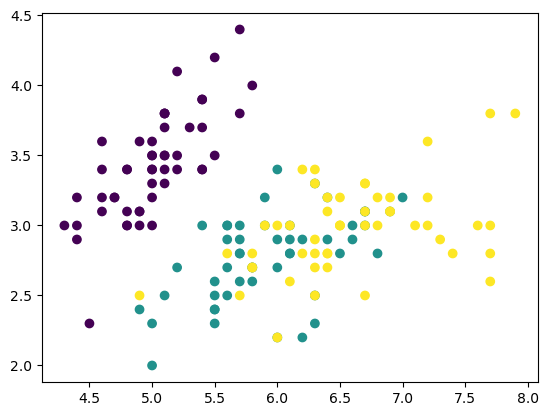

In [101]:
plt.scatter( X[:,0], X[:,1] , c = y  )

In [102]:
X_train , X_test ,  Y_train  , Y_test = train_test_split(X , y  , test_size=0.2)

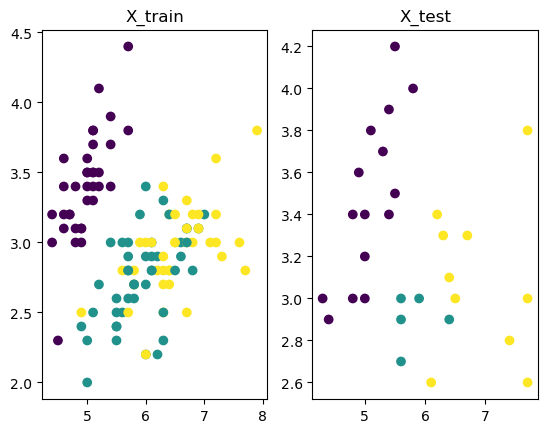

In [103]:
plt.Figure(figsize=(15,4))
plt.subplot(121)
plt.title("X_train")
plt.scatter( X_train[:,0], X_train[:,1] , c = Y_train  )

plt.subplot(122)
plt.title("X_test")
plt.scatter( X_test[:,0], X_test[:,1] , c = Y_test  )

In [104]:
model = KNeighborsClassifier(n_neighbors=1)
model.fit(X_train , Y_train)
print("Train score " , model.score(X_train , Y_train))
print("Test score " , model.score(X_test , Y_test))

Train score  1.0
Test score  1.0


In [105]:
cross_val_score(KNeighborsClassifier() , X_train , Y_train , cv=5 , scoring='accuracy').mean()


0.95

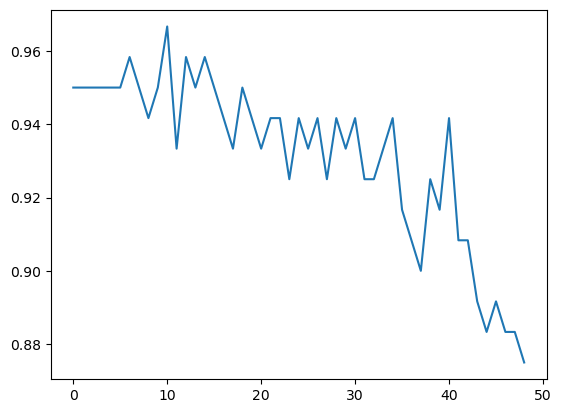

In [106]:
my_train_score = []
for k in range(1,50):
    my_train_score.append(cross_val_score(KNeighborsClassifier(k) , X_train , Y_train , cv=5 , scoring='accuracy').mean())

plt.plot(my_train_score)
    

# autre manier de le faire avec validation_curve

In [107]:
k = np.arange(1,50)
train_scores, val_scores = validation_curve(model, X_train, Y_train, param_name='n_neighbors', param_range=k, cv=5)

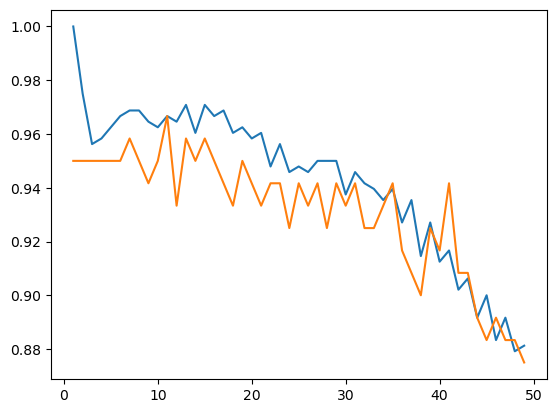

In [108]:
plt.figure()
plt.plot(k,train_scores.mean(axis=1))
plt.plot(k,val_scores.mean(axis=1))

In [109]:
mes_parametre = {
    'n_neighbors': np.arange(1,20),
    'metric' : [ 'euclidean' , 'manhattan' ]
}

my_grid = GridSearchCV( KNeighborsClassifier() , mes_parametre , cv=5 )

my_grid.fit( X_train , Y_train )


GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19])})

In [110]:
print('mon best score est : ' , my_grid.best_score_)

mon best score est :  0.9666666666666666


In [111]:
print('mes meilleurs paramtres sont : ' , my_grid.best_params_)

mes meilleurs paramtres sont :  {'metric': 'euclidean', 'n_neighbors': 11}


In [112]:
print('mon best score est : ' , my_grid.best_estimator_)

mon best score est :  KNeighborsClassifier(metric='euclidean', n_neighbors=11)


In [113]:
#pour sauvegader notre model 
meilleur_model = my_grid.best_estimator_

In [114]:
meilleur_model.score(X_test , Y_test)

1.0

In [115]:
from sklearn.metrics import confusion_matrix

In [116]:
confusion_matrix( Y_test , meilleur_model.predict( X_test ) )

array([[15,  0,  0],
       [ 0,  5,  0],
       [ 0,  0, 10]], dtype=int64)

In [117]:
from sklearn.model_selection import learning_curve , GroupKFold

In [118]:
cv = GroupKFold(5).get_n_splits(X , y , groups=X[:,0])
N , train_score , vali_scores = learning_curve( KNeighborsClassifier() , X_train , Y_train , train_sizes=np.linspace(0.1 ,1.0 , 10 ) , cv=cv ) 

In [119]:
print(N) # N est le nombre d'element pour chaque pourcenetage de decoupage de  1 a 100

[ 9 19 28 38 48 57 67 76 86 96]


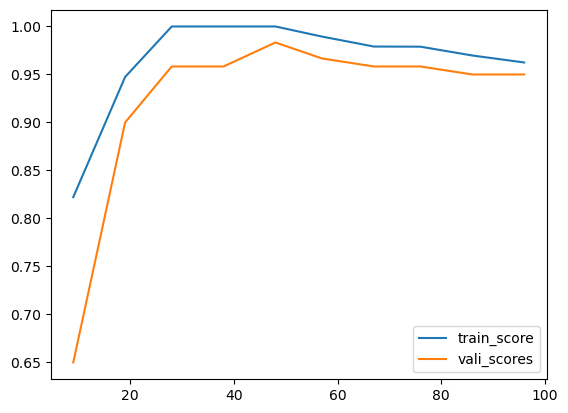

In [120]:
plt.plot( N , train_score.mean(axis=1) , label = 'train_score')
plt.plot( N , vali_scores.mean(axis=1) , label = 'vali_scores' )
plt.legend()

# PRE-PROCESSING

## Encodage


#### --Ordinale 

permet associer chaque categorier d'une variable a une valeur numerique 

In [121]:
from sklearn.preprocessing import LabelEncoder
## ce module permet de transformer une seul variable 

In [122]:
encodage =  LabelEncoder()
y = np.array(['chat' , 'chien' , 'mouton' , 'chat' , 'coq' , 'mouton'])

In [123]:
encodage.fit(y)
encodage.classes_ 


array(['chat', 'chien', 'coq', 'mouton'], dtype='<U6')

In [124]:
encodage.transform(y) # pour transformer chaque chaine a une valeur numerique 

array([0, 1, 3, 0, 2, 3])

In [125]:
# on peux faire les deux en meme temps
resultat_de_ma_transformation = encodage.fit_transform(y)

In [126]:
##pour inverser la transformation on peux utiliser ""inverse_transform""
encodage.inverse_transform(resultat_de_ma_transformation)

array(['chat', 'chien', 'mouton', 'chat', 'coq', 'mouton'], dtype='<U6')

In [127]:
# cette methode ne êrmet pas de convertire toutes les type de variable 
# mieux c'est d'utiliser OrdinalEncoder a la place de lebalEncoder

#### --Binaire 

In [128]:
from sklearn.preprocessing import LabelBinarizer , OneHotEncoder , OrdinalEncoder

In [129]:
mon_encodage = LabelBinarizer()
resultat_de_ma_transformation = mon_encodage.fit_transform(y) # permet de transformer sous forme de table 
resultat_de_ma_transformation

array([[1, 0, 0, 0],
       [0, 1, 0, 0],
       [0, 0, 0, 1],
       [1, 0, 0, 0],
       [0, 0, 1, 0],
       [0, 0, 0, 1]])

In [130]:
y = np.array([['chat', 'chien'] ,
              ['mouton' ,'chat'] ,
              ['coq', 'mouton' ],
              ['chat', 'chien'] ,
              ['mouton', 'chat'], 
              ['coq', 'mouton']])

mon_encodage  = OneHotEncoder()
resultat_de_ma_transformation = mon_encodage.fit_transform(y)
print(resultat_de_ma_transformation)

  (0, 0)	1.0
  (0, 4)	1.0
  (1, 2)	1.0
  (1, 3)	1.0
  (2, 1)	1.0
  (2, 5)	1.0
  (3, 0)	1.0
  (3, 4)	1.0
  (4, 2)	1.0
  (4, 3)	1.0
  (5, 1)	1.0
  (5, 5)	1.0


# la normalisation
### on a 3 types de normalisation 

In [131]:
from sklearn.preprocessing import MinMaxScaler , StandardScaler , RobustScaler
mes_val = np.array([ [1],[2],[3],[4],[5],[6],[7],[8],[9] ])
normalisation = MinMaxScaler()

resultat_normalisation = normalisation.fit_transform(mes_val)
print(resultat_normalisation)


[[0.   ]
 [0.125]
 [0.25 ]
 [0.375]
 [0.5  ]
 [0.625]
 [0.75 ]
 [0.875]
 [1.   ]]


In [132]:
normalisation = StandardScaler()

resultat_normalisation = normalisation.fit_transform(mes_val)
print(resultat_normalisation)

[[-1.54919334]
 [-1.161895  ]
 [-0.77459667]
 [-0.38729833]
 [ 0.        ]
 [ 0.38729833]
 [ 0.77459667]
 [ 1.161895  ]
 [ 1.54919334]]


##### ces deux technique precedent ne son pas efficace si nous avont des valeur aberant 
##### mieux c'est d'utiliser RobustScaler

In [133]:
normalisation = RobustScaler()

resultat_normalisation = normalisation.fit_transform(mes_val)
print(resultat_normalisation)

[[-1.  ]
 [-0.75]
 [-0.5 ]
 [-0.25]
 [ 0.  ]
 [ 0.25]
 [ 0.5 ]
 [ 0.75]
 [ 1.  ]]


In [134]:
X = iris.data
y = iris.target

X_train , X_test , Y_train , Y_test = train_test_split(X, y , train_size=0.3)
scaler = StandardScaler()
X_train_transforme = scaler.fit_transform(X_train)
model = KNeighborsClassifier()
model.fit(X_train_transforme , Y_train)

X_test_transforme = scaler.fit_transform(X_test)

model.score(X_test_transforme , Y_test)

0.8571428571428571

# Pipepline
#nous permet de refaire le code precedent de manier plus facule

In [135]:
#exemple
from sklearn.pipeline import make_pipeline
model =  make_pipeline( StandardScaler() , KNeighborsClassifier()  )

model.fit(X_train , Y_train)
model.score(X_test , Y_test)

0.8666666666666667

In [136]:
import seaborn as sns
titanic = sns.load_dataset('titanic')

In [137]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [138]:
X_titanic = titanic.drop('survived' , axis=1)  
y_titanic= titanic['survived']

In [139]:
X_titanic.head()

,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [140]:
from sklearn.compose import make_column_transformer
transformeur = make_column_transformer(( StandardScaler() , [ 'age' , 'fare' ] ))
from sklearn.linear_model import SGDClassifier

transformeur.fit_transform(X_titanic)



array([[-0.53037664, -0.50244517],
       [ 0.57183099,  0.78684529],
       [-0.25482473, -0.48885426],
       ...,
       [        nan, -0.17626324],
       [-0.25482473, -0.04438104],
       [ 0.15850313, -0.49237783]])

In [141]:
#autre methode en utilisant les pipeplane
from sklearn.impute import SimpleImputer # c'est pour enlever les valeur manquante

#mes variables numeriques 
numerical_feature = [ 'pclass' , 'age' , 'fare' ]

#mes variables categoriels
categoriel_feature = [ 'sex' , 'deck' , 'alone' ]


####### il existe d'autre methode pour faire la separation des variable dans le moddule compose de sklearn 

from sklearn.compose import make_column_selector

#mes variables numeriques 
numerical_feature = make_column_selector( dtype_include= np.number )

#mes variables categoriels
categoriel_feature = make_column_selector( dtype_exclude=np.number )




numerical_pipeplane = make_pipeline( SimpleImputer() , StandardScaler() )

categoriel_pipeplane = make_pipeline( SimpleImputer( strategy= 'most_frequent' ) , OneHotEncoder() )


# notre preprocesseur 
preprocesseur = make_column_transformer( ( numerical_pipeplane , numerical_feature ),
                          ( categoriel_pipeplane , categoriel_feature ) )

#pipeplane finale
notre_model = make_pipeline( preprocesseur , SGDClassifier() )

notre_model.fit( X_titanic , y_titanic )

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x000002097727A6C0>),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000020977258CB0>)])),
                ('sgdclassifier', SGDClassifier())])

### autre methode Pour trier les variable a transformer 

# Lest Transformeurs
#ils nous permettent de transformer notre dataset 

In [142]:
 my_data = np.array( [[2 ,3] ,[4 ,np.nan] ,[6 ,7] ,[8 ,9] , [np.nan,7]]  )

In [143]:
from sklearn.impute import SimpleImputer
model = SimpleImputer( missing_values=np.nan , strategy= 'mean' )
model.fit_transform(my_data)

array([[2. , 3. ],
       [4. , 6.5],
       [6. , 7. ],
       [8. , 9. ],
       [5. , 7. ]])

In [144]:
from sklearn.impute import KNNImputer
my_data = np.array( [[2 ,3] ,[4 ,np.nan] ,[6 ,7] ,[8 ,9] , [np.nan,7]]  )
print(my_data)
model = KNNImputer(n_neighbors=1)
model.fit_transform(my_data)

[[ 2.  3.]
 [ 4. nan]
 [ 6.  7.]
 [ 8.  9.]
 [nan  7.]]


array([[2., 3.],
       [4., 3.],
       [6., 7.],
       [8., 9.],
       [6., 7.]])

### Feature Selection

In [150]:
from sklearn.feature_selection import VarianceThreshold # nous permetrat d'eliminer les colonnes celon certain variable

X = iris.data
y = iris.target

X.var(axis=0) # pour voir la vairiande de toutes les colones

array([0.68112222, 0.18871289, 3.09550267, 0.57713289])

In [166]:
selecteur = VarianceThreshold( threshold=0.2 ) # si nous voulons par exemples selection que les variance sueperieur a 0.2
selecteur.fit_transform(X)
variable_selectionne = selecteur.get_support() # nous retour un tableau boulean  contenant les colonne que respecte bien la variance
variable_selectionne


array([ True, False,  True,  True])

In [169]:
nos_colonne = iris.feature_names # nous retourne ne nom de nos different colone 
nos_colonne = np.array(nos_colonne) # je le convetie de tablea
nos_colonne


array(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'], dtype='<U17')

In [171]:
nos_colonne[variable_selectionne] # ici nous avons que les colonnes qui respecte que notre variance fixe

array(['sepal length (cm)', 'petal length (cm)', 'petal width (cm)'],
      dtype='<U17')